In [40]:
import os 
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import numpy as np
import pandas as pd

In [41]:
os.chdir("/home/aadityasharma/Desktop/Aaditya_Sharma_Trainee_Hestabit/Week_6")
print(os.getcwd())

/home/aadityasharma/Desktop/Aaditya_Sharma_Trainee_Hestabit/Week_6


In [42]:
DATA_PATH = "src/data/raw/diabetes.csv"
print("DATA_PATH :", DATA_PATH)

DATA_PATH : src/data/raw/diabetes.csv


In [43]:
df = pd.read_csv(DATA_PATH)
print("Dataset shape :", df.shape)
df.head()

Dataset shape : (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [44]:
print("Dataset information")
df.info()

Dataset information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [45]:
print("Dataset statistical info")

df.describe()

Dataset statistical info


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [46]:
cols = df.columns.drop('Outcome')
df[cols] = df[cols].replace(0, np.nan)

In [47]:
print("Missing value summary")

df.isnull().sum()

Missing value summary


Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

### Missing value heatmap ---> Missingo (msno)

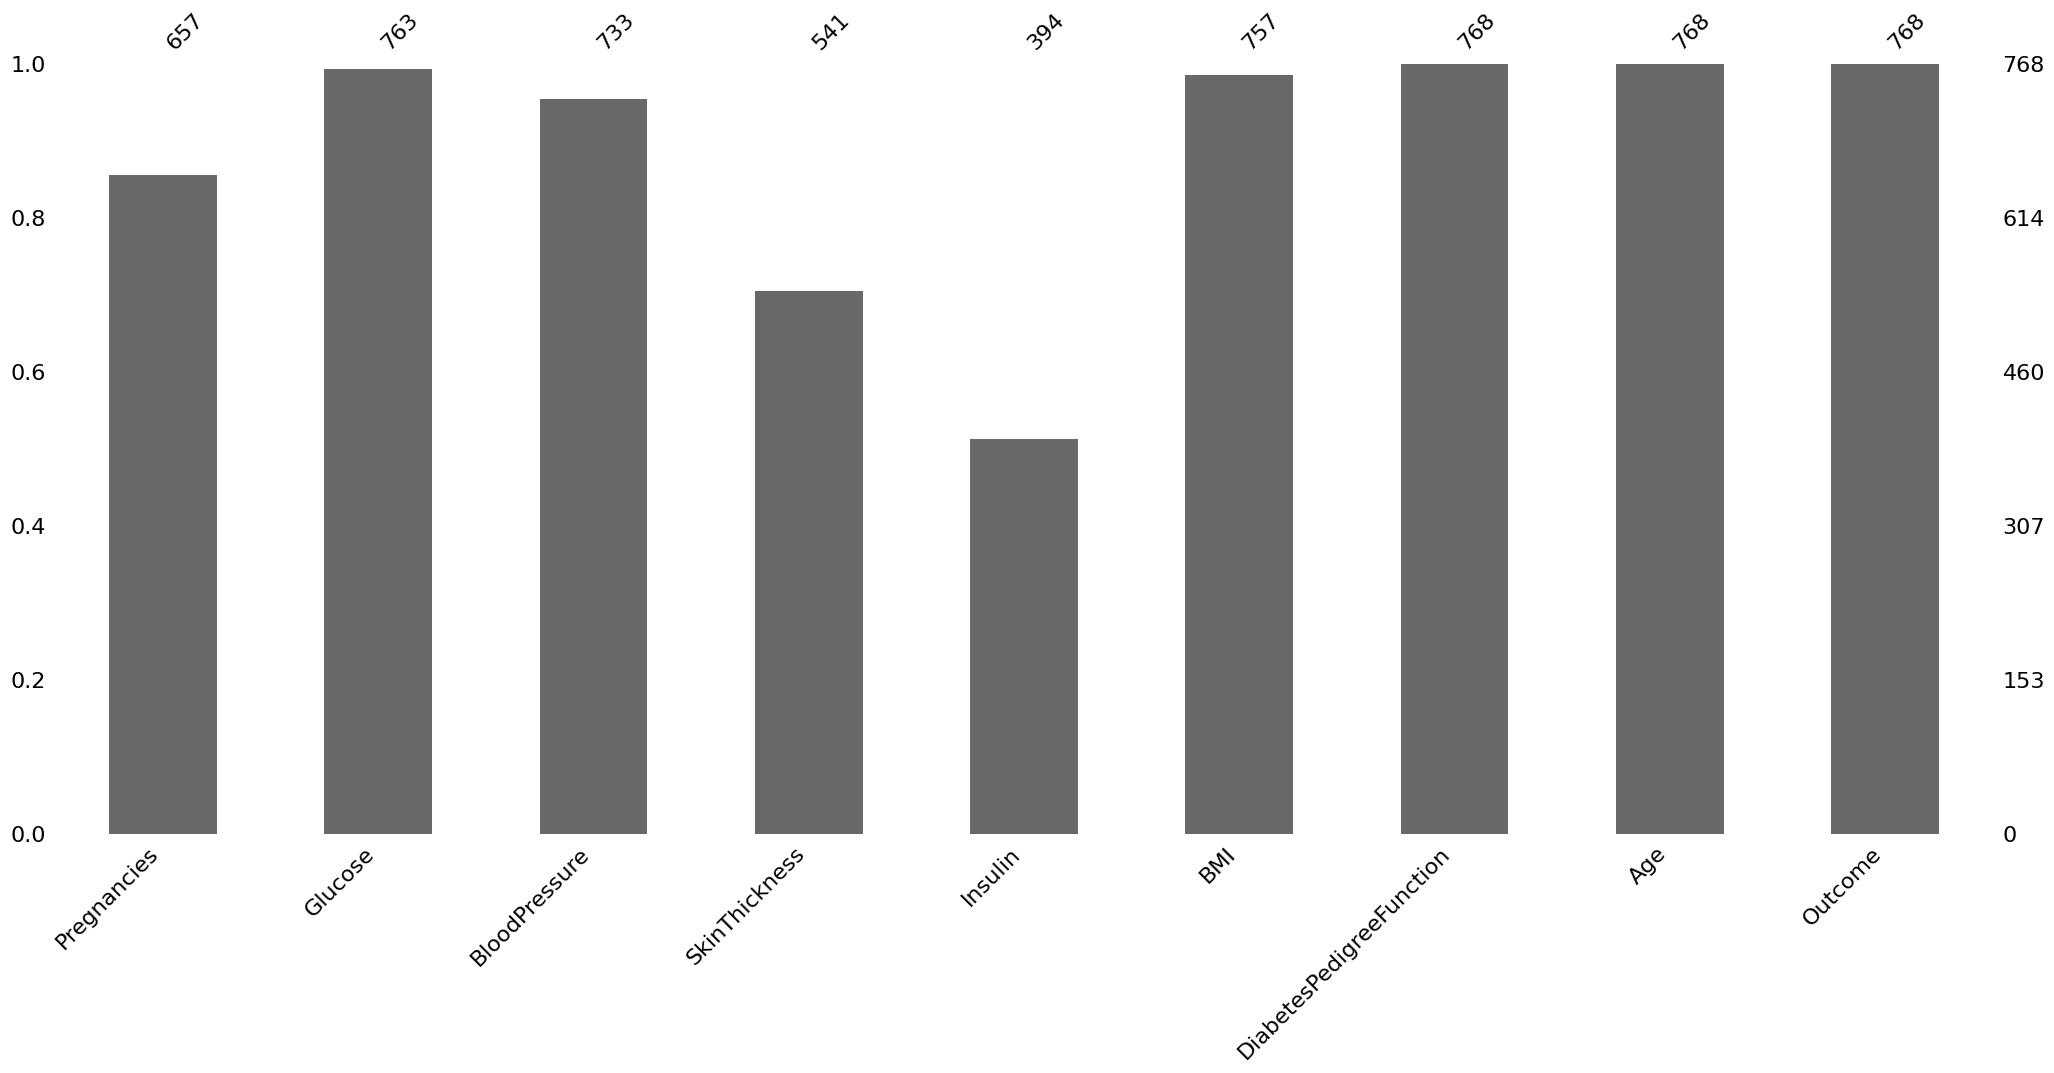

In [48]:
plt.figure(figsize=(8,6))
msno.bar(df)
plt.show()

### For Correlation matrix ---> corr and seaborn(sns)

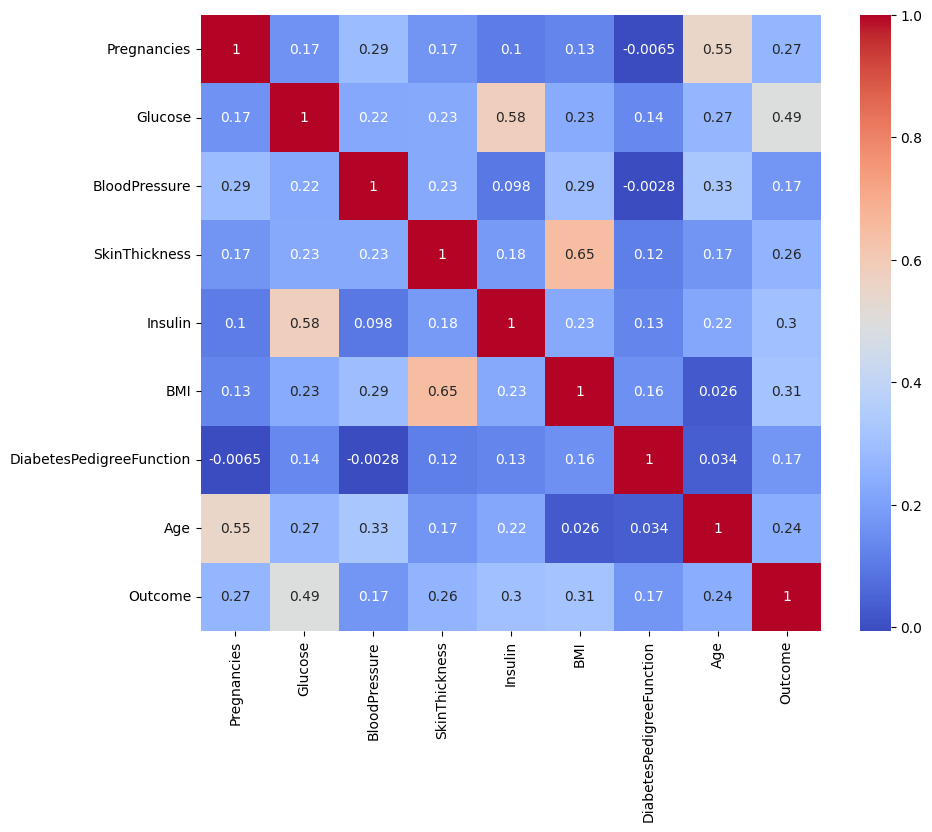

In [49]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

### Target Distribution ---> Outcome xlabel ylabel

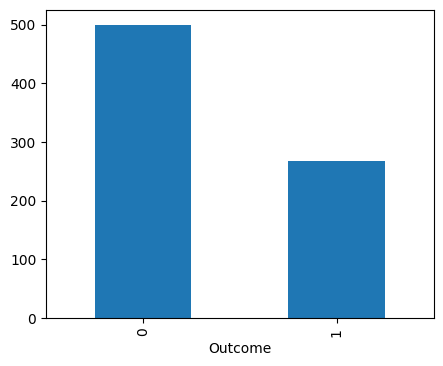

In [50]:
plt.figure(figsize=(5,4))
df["Outcome"].value_counts().plot(kind="bar")
plt.show()


### Feature Distribution

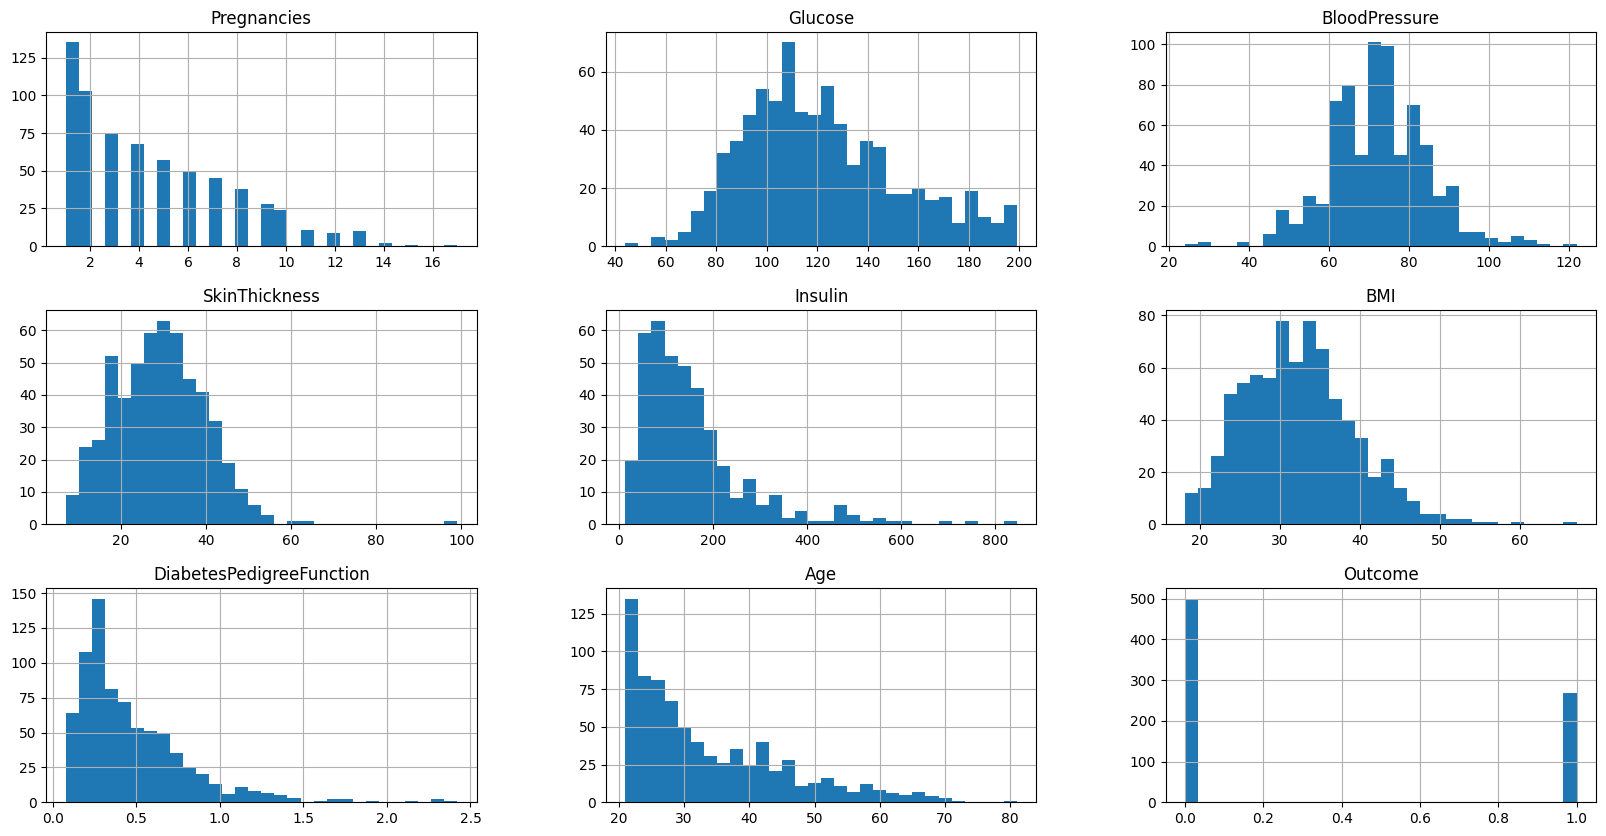

In [51]:
numeric_cols = df.select_dtypes(include="number").columns
df[numeric_cols].hist(figsize=(20,10), bins=30)
plt.show()

## Outliers

<Axes: >

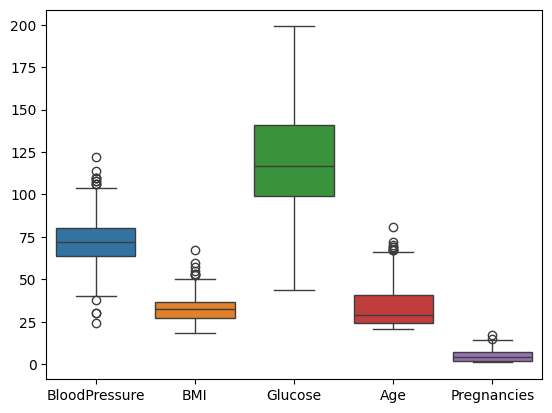

In [52]:
sns.boxplot(data=df[['BloodPressure','BMI','Glucose','Age','Pregnancies']])